<a href="https://colab.research.google.com/github/1kaiser/superpoint-jax/blob/main/demo/compare_jax_torch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/1kaiser/superpoint-jax

Cloning into 'superpoint-jax'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 114 (delta 43), reused 94 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (114/114), 11.46 MiB | 18.05 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [2]:
import os
import numpy as np
import cv2
import torch

import jax.numpy as jnp

100%|██████████| 341k/341k [00:00<00:00, 4.60MB/s]


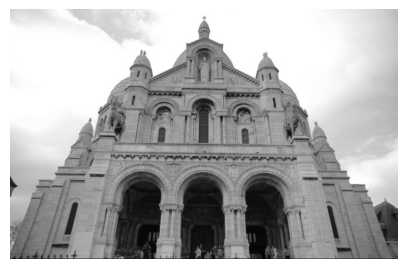

In [3]:
# Download image from URL.
image_url = 'https://raw.githubusercontent.com/cvg/Hierarchical-Localization/master/datasets/sacre_coeur/mapping/03903474_1471484089.jpg'
image_path = 'image_sacre_coeur.jpg'
torch.hub.download_url_to_file(image_url, image_path)

# For plotting, assume you have a helper function. Here we use matplotlib.
import matplotlib.pyplot as plt

def plot_imgs(imgs, cmap=None):
    """Simple helper to plot a list of images."""
    n = len(imgs)
    plt.figure(figsize=(5*n, 5))
    for i, img in enumerate(imgs):
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap=cmap)
        plt.axis('off')
    plt.show()

# Read the image with OpenCV, convert to grayscale and normalize.
image = cv2.imread(image_path)
if image is None:
    raise ValueError("Failed to read image from " + image_path)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

# Pad image so that its dimensions are multiples of 8.
padded = []
for s in image_gray.shape:
    pad = int(np.ceil(s/8)*8 - s)
    padded.append((0, pad))
image_padded = np.pad(image_gray, padded, mode='constant')
plot_imgs([image_padded], cmap='gray')

In [6]:
!pwd

/content


In [7]:
%cd superpoint-jax

/content/superpoint-jax


In [10]:
from superpoint_jax import SuperPointTorch

# Instantiate the PyTorch model.
torch_model = SuperPointTorch()
# Load the pretrained weights (assumes a file named 'superpoint_torch_weights.pth' exists).
torch_checkpoint = "weights/superpoint_torch.pth"
if not os.path.exists(torch_checkpoint):
    raise FileNotFoundError(f"PyTorch checkpoint {torch_checkpoint} not found.")
torch_state = torch.load(torch_checkpoint, map_location="cpu")
torch_model.load_state_dict(torch_state)
torch_model.eval()
print("Loaded PyTorch SuperPoint model.")

Loaded PyTorch SuperPoint model.


In [11]:
from superpoint_jax import SuperPointJAX
from superpoint_jax.utils import convert_superpoint_weights
from flax.serialization import to_bytes, from_bytes
from flax import nnx

# Create the JAX model with the same configuration as the torch model.
jax_model = SuperPointJAX(rngs=nnx.Rngs(0))
print("Created JAX SuperPoint model.")

# Convert weights: this copies parameters from the torch model into the jax model.
jax_model = convert_superpoint_weights(torch_model, jax_model)
print("Converted PyTorch weights to JAX.")

Created JAX SuperPoint model.
Converted PyTorch weights to JAX.


In [12]:
dummy_torch = torch.from_numpy(image_padded[None, None, ...]).float()  # add batch and channel dims
dummy_jax = jnp.array(image_padded[None, ..., None], dtype=jnp.float32)

# --- Run the Torch model forward pass ---
with torch.no_grad():
    torch_output = torch_model.forward({"image": dummy_torch})
# torch_output is a dict with keys "keypoints", "keypoint_scores", "descriptors"
num_keypoints_torch = [k.shape[0] for k in torch_output["keypoints"]]
print("PyTorch detected keypoints:", num_keypoints_torch)

# --- Run the JAX model forward pass ---
jax_output = jax_model(dummy_jax, training=False)
# jax_output is a dict with keys "keypoints", "scores", "descriptors", "valid_counts"
if "valid_counts" in jax_output:
    num_keypoints_jax = int(jax_output["valid_counts"][0])
else:
    num_keypoints_jax = int(jnp.sum(jnp.where(jax_output["scores"] > -1, 1, 0)))
print("JAX detected keypoints (approx):", num_keypoints_jax)

PyTorch detected keypoints: [3203]
JAX detected keypoints (approx): 3203


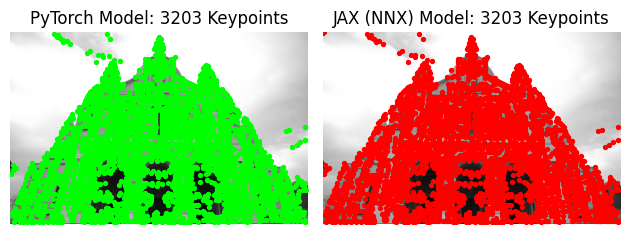

In [13]:
import matplotlib.pyplot as plt
import numpy as np

torch_kpts = torch_output["keypoints"][0].cpu().numpy()  # shape (N, 2)
jax_kpts = np.array(jax_output["keypoints"][0])  # shape (N, 2)

fig, axs = plt.subplots(1, 2,
                        # figsize=(16, 8)
                        )

axs[0].imshow(image_padded, cmap="gray")
if torch_kpts.size > 0:
    axs[0].scatter(torch_kpts[:, 0], torch_kpts[:, 1], s=8, c='lime', marker='o')
axs[0].set_title(f"PyTorch Model: {torch_kpts.shape[0]} Keypoints")
axs[0].axis("off")

axs[1].imshow(image_padded, cmap="gray")
if jax_kpts.size > 0:
    axs[1].scatter(jax_kpts[:, 1], jax_kpts[:, 0], s=8, c='red', marker='o')
axs[1].set_title(f"JAX (NNX) Model: { int(jax_output['valid_counts'][0]) } Keypoints")
axs[1].axis("off")

plt.tight_layout()
plt.show()

In [15]:
jax_state = nnx.state(jax_model).to_pure_dict()

jax_save_path = "weights/superpoint_nnx.msgpack"
with open(jax_save_path, "wb") as f:
    f.write(to_bytes(jax_state))
print(f"Saved JAX model state to {jax_save_path}")

Saved JAX model state to weights/superpoint_nnx.msgpack


Reloaded JAX model with saved state.
JAX model output keys: ['keypoints', 'scores', 'descriptors', 'valid_counts']
Valid keypoints count: [3203]


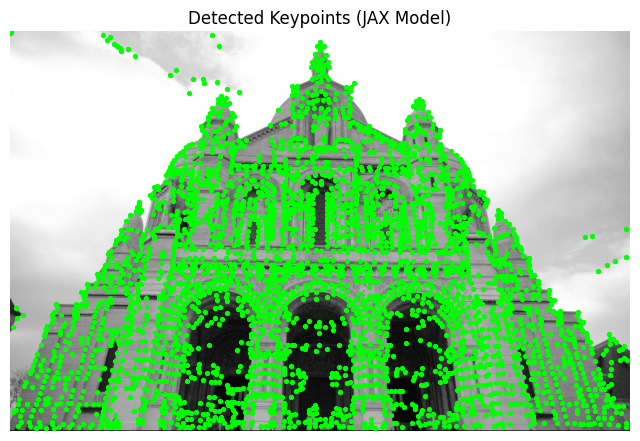

In [16]:
with open(jax_save_path, "rb") as f:
    loaded_state = from_bytes(jax_state, f.read())

jax_model_reloaded = SuperPointJAX(rngs=nnx.Rngs(0))
# Update the model with the loaded state.
nnx.update(jax_model_reloaded, loaded_state)
print("Reloaded JAX model with saved state.")

# Prepare the image for JAX: image_padded is already normalized.
input_jax = jnp.array(image_padded[None, ..., None], dtype=jnp.float32)
# Run the model.
jax_result = jax_model_reloaded(input_jax, training=False)
print("JAX model output keys:", list(jax_result.keys()))
print("Valid keypoints count:", jax_result.get("valid_counts", "Not provided"))

keypoints = jax_result["keypoints"][0]  # shape (N, 2)
keypoints = np.array(keypoints)  # convert from jax DeviceArray to numpy

plt.figure(figsize=(8, 6))
plt.imshow(image_padded, cmap="gray")
if keypoints.size > 0:
    plt.scatter(keypoints[:, 1], keypoints[:, 0], s=8, c="lime", marker="o")
plt.title("Detected Keypoints (JAX Model)")
plt.axis("off")
plt.show()

## JS/ONNX Inference Comparison

Run the SuperPoint ONNX model via the JavaScript inference script and compare
keypoint detections across all three implementations: **PyTorch**, **JAX**, and **JS/ONNX**.

**Prerequisites:** `superpoint.onnx` (from `export_to_onnx.py`) and `jax-js/` deps installed.

In [24]:
# Move into the folder, install, and move back
%cd /content/superpoint-jax/jax-js
!npm install onnxruntime-node sharp
%cd /content/superpoint-jax

/content/superpoint-jax/jax-js
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏npm warn deprecated boolean@3.2.0: Package no longer supported. Contact Support at https://www.npmjs.com/support for more info.
⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 36 packages, and audited 37 packages in 30s
⠸
⠸13 packages are looking for funding
⠸  run `npm fund` for details
⠸
found 0 vulnerabilities
⠸npm notice
npm notice New major version of npm available! 10.8.2 -> 11.10.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.10.0
npm notice To update run: npm install -g npm@11.10.0
npm notice
⠸/content/superpoint-jax


In [25]:
import subprocess
import json as json_mod
import os
import numpy as np
import cv2

# 1. Define Paths based on your structure
BASE_DIR = "/content/superpoint-jax"
JS_DIR = os.path.join(BASE_DIR, "jax-js")
JS_SCRIPT_PATH = os.path.join(JS_DIR, "compare_helper.js")
IMAGE_PATH = os.path.join(BASE_DIR, "image_sacre_coeur_gray.png")
OUTPUT_JSON = os.path.join(BASE_DIR, "js_keypoints.json")
ONNX_MODEL = os.path.join(BASE_DIR, "superpoint.onnx")

# 2. Install Node.js dependencies (onnxruntime-node and sharp)
# We use --prefix to ensure they are installed inside the jax-js folder
if not os.path.exists(os.path.join(JS_DIR, "node_modules")):
    print("Installing Node.js dependencies in jax-js folder...")
    subprocess.run(["npm", "install", "--prefix", JS_DIR, "onnxruntime-node", "sharp"], check=True)

# 3. Define the JS Helper Code
js_helper_code = r'''
const ort = require("onnxruntime-node");
const sharp = require("sharp");
const path = require("path");
const fs = require("fs");

// Points to /content/superpoint-jax/superpoint.onnx
const MODEL_PATH = path.join(__dirname, "..", "superpoint.onnx");

function maxPool2D(data, height, width, radius) {
  const output = new Float32Array(height * width);
  for (let y = 0; y < height; y++) {
    for (let x = 0; x < width; x++) {
      let maxVal = -Infinity;
      for (let ky = -radius; ky <= radius; ky++) {
        for (let kx = -radius; kx <= radius; kx++) {
          const ny = y + ky;
          const nx = x + kx;
          if (ny >= 0 && ny < height && nx >= 0 && nx < width) {
            maxVal = Math.max(maxVal, data[ny * width + nx]);
          }
        }
      }
      output[y * width + x] = maxVal;
    }
  }
  return output;
}

function pixelShuffle(data, channels, heightCells, widthCells, stride) {
  const fullHeight = heightCells * stride;
  const fullWidth = widthCells * stride;
  const output = new Float32Array(fullHeight * fullWidth);
  for (let cy = 0; cy < heightCells; cy++) {
    for (let cx = 0; cx < widthCells; cx++) {
      for (let c = 0; c < channels; c++) {
        const y = cy * stride + Math.floor(c / stride);
        const x = cx * stride + (c % stride);
        output[y * fullWidth + x] = data[c * heightCells * widthCells + cy * widthCells + cx];
      }
    }
  }
  return { data: output, height: fullHeight, width: fullWidth };
}

function nonMaximumSuppression(scores, height, width, radius) {
  const maxPooled = maxPool2D(scores, height, width, radius);
  const mask = new Uint8Array(height * width);
  for (let i = 0; i < height * width; i++) mask[i] = scores[i] === maxPooled[i] ? 1 : 0;
  for (let iteration = 0; iteration < 2; iteration++) {
    const maskFloat = new Float32Array(height * width);
    for (let i = 0; i < height * width; i++) maskFloat[i] = mask[i];
    const suppressedPool = maxPool2D(maskFloat, height, width, radius);
    const suppressedMask = new Uint8Array(height * width);
    for (let i = 0; i < height * width; i++) suppressedMask[i] = suppressedPool[i] > 0 ? 1 : 0;
    const remainingScores = new Float32Array(height * width);
    for (let i = 0; i < height * width; i++) remainingScores[i] = suppressedMask[i] ? 0 : scores[i];
    const secondaryPool = maxPool2D(remainingScores, height, width, radius);
    for (let i = 0; i < height * width; i++) {
      if (remainingScores[i] === secondaryPool[i] && remainingScores[i] > 0 && !suppressedMask[i]) mask[i] = 1;
    }
  }
  const result = new Float32Array(height * width);
  for (let i = 0; i < height * width; i++) result[i] = mask[i] ? scores[i] : 0;
  return result;
}

function removeBorders(data, height, width, padding) {
  for (let y = 0; y < height; y++) {
    for (let x = 0; x < width; x++) {
      if (y < padding || y >= height - padding || x < padding || x >= width - padding) data[y * width + x] = -1;
    }
  }
}

function extractKeypoints(scores, height, width, threshold) {
  const keypoints = [];
  for (let y = 0; y < height; y++) {
    for (let x = 0; x < width; x++) {
      const score = scores[y * width + x];
      if (score > threshold) keypoints.push({ x, y, score });
    }
  }
  return keypoints.sort((a, b) => b.score - a.score);
}

(async () => {
  const inputImg = process.argv[2];
  const outputJson = process.argv[3];

  const session = await ort.InferenceSession.create(MODEL_PATH);
  const image = await sharp(inputImg).greyscale().raw().toBuffer({ resolveWithObject: true });

  const { height: oH, width: oW } = image.info;
  const pH = oH % 8 === 0 ? 0 : 8 - (oH % 8);
  const pW = oW % 8 === 0 ? 0 : 8 - (oW % 8);
  const H = oH + pH, W = oW + pW;

  const floatBuffer = new Float32Array(H * W);
  for (let y = 0; y < oH; y++) {
    for (let x = 0; x < oW; x++) floatBuffer[y * W + x] = image.data[y * oW + x] / 255.0;
  }

  const inputTensor = new ort.Tensor("float32", floatBuffer, [1, 1, H, W]);
  const outputs = await session.run({ image: inputTensor });

  const { data: sM, height: sH, width: sW } = pixelShuffle(outputs.scores.data, 64, outputs.scores.dims[2], outputs.scores.dims[3], 8);
  const nmsS = nonMaximumSuppression(sM, sH, sW, 4);
  removeBorders(nmsS, sH, sW, 4);
  const kpts = extractKeypoints(nmsS, sH, sW, 0.005);

  fs.writeFileSync(outputJson, JSON.stringify({
    keypoints: kpts.map(k => [k.x, k.y]),
    scores: kpts.map(k => k.score)
  }));
  console.log(`Saved ${kpts.length} keypoints`);
})();
'''

# 4. Write the JS script to file
with open(JS_SCRIPT_PATH, 'w') as f:
    f.write(js_helper_code)

# 5. Run the Node script
# We set cwd=JS_DIR so Node finds the local node_modules
print("Running Node.js SuperPoint inference...")
result = subprocess.run(
    ['node', 'compare_helper.js', IMAGE_PATH, OUTPUT_JSON],
    cwd=JS_DIR,
    capture_output=True,
    text=True
)

# 6. Check for errors and load result
if result.returncode != 0:
    print("--- NODE.JS ERROR ---")
    print(result.stderr)
else:
    print("Node.js Output:", result.stdout.strip())
    if os.path.exists(OUTPUT_JSON):
        with open(OUTPUT_JSON, 'r') as f:
            js_data = json_mod.load(f)

        js_kpts = np.array(js_data['keypoints'])
        js_scores = np.array(js_data['scores'])
        print(f"Comparison Success: Loaded {len(js_kpts)} keypoints from JS/ONNX.")
        print(f"Top Score: {js_scores.max():.4f}")
    else:
        print("Error: JSON output file was not created.")

Running Node.js SuperPoint inference...
Node.js Output: Saved 3203 keypoints
Comparison Success: Loaded 3203 keypoints from JS/ONNX.
Top Score: 0.6669


In [22]:
!apt install tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (97.2 kB/s)
Selecting previously unselected package tree.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [23]:
!tree /content/superpoint-jax

/content/superpoint-jax
├── demo
│   └── compare_jax_torch.ipynb
├── export_to_onnx.py
├── image_sacre_coeur_gray.png
├── jax-js
│   ├── compare_helper.js
│   ├── package.json
│   ├── package-lock.json
│   └── superpoint_jax_js.js
├── LICENSE
├── README.md
├── requirements.txt
├── setup.py
├── superpoint_jax
│   ├── __init__.py
│   ├── model
│   │   ├── __init__.py
│   │   ├── __pycache__
│   │   │   ├── __init__.cpython-312.pyc
│   │   │   ├── superpoint_jax.cpython-312.pyc
│   │   │   └── superpoint_torch.cpython-312.pyc
│   │   ├── superpoint_jax.py
│   │   └── superpoint_torch.py
│   ├── __pycache__
│   │   └── __init__.cpython-312.pyc
│   └── utils
│       ├── convert_to_jax.py
│       ├── __init__.py
│       └── __pycache__
│           ├── convert_to_jax.cpython-312.pyc
│           └── __init__.cpython-312.pyc
├── superpoint.onnx
└── weights
    ├── superpoint_nnx.msgpack
    └── superpoint_torch.pth

9 directories, 26 files


In [21]:
!ls -lah

total 5.4M
drwxr-xr-x 7 root root 4.0K Feb 16 16:53 .
drwxr-xr-x 1 root root 4.0K Feb 16 16:51 ..
drwxr-xr-x 2 root root 4.0K Feb 16 16:48 demo
-rw-r--r-- 1 root root 3.4K Feb 16 16:48 export_to_onnx.py
drwxr-xr-x 8 root root 4.0K Feb 16 16:48 .git
-rw-r--r-- 1 root root 3.6K Feb 16 16:48 .gitignore
-rw-r--r-- 1 root root 320K Feb 16 16:54 image_sacre_coeur_gray.png
drwxr-xr-x 2 root root 4.0K Feb 16 16:54 jax-js
-rw-r--r-- 1 root root 1.1K Feb 16 16:48 LICENSE
-rw-r--r-- 1 root root 3.3K Feb 16 16:48 README.md
-rw-r--r-- 1 root root   24 Feb 16 16:48 requirements.txt
-rw-r--r-- 1 root root  876 Feb 16 16:48 setup.py
drwxr-xr-x 5 root root 4.0K Feb 16 16:52 superpoint_jax
-rw-r--r-- 1 root root 5.0M Feb 16 16:48 superpoint.onnx
drwxr-xr-x 2 root root 4.0K Feb 16 16:48 weights


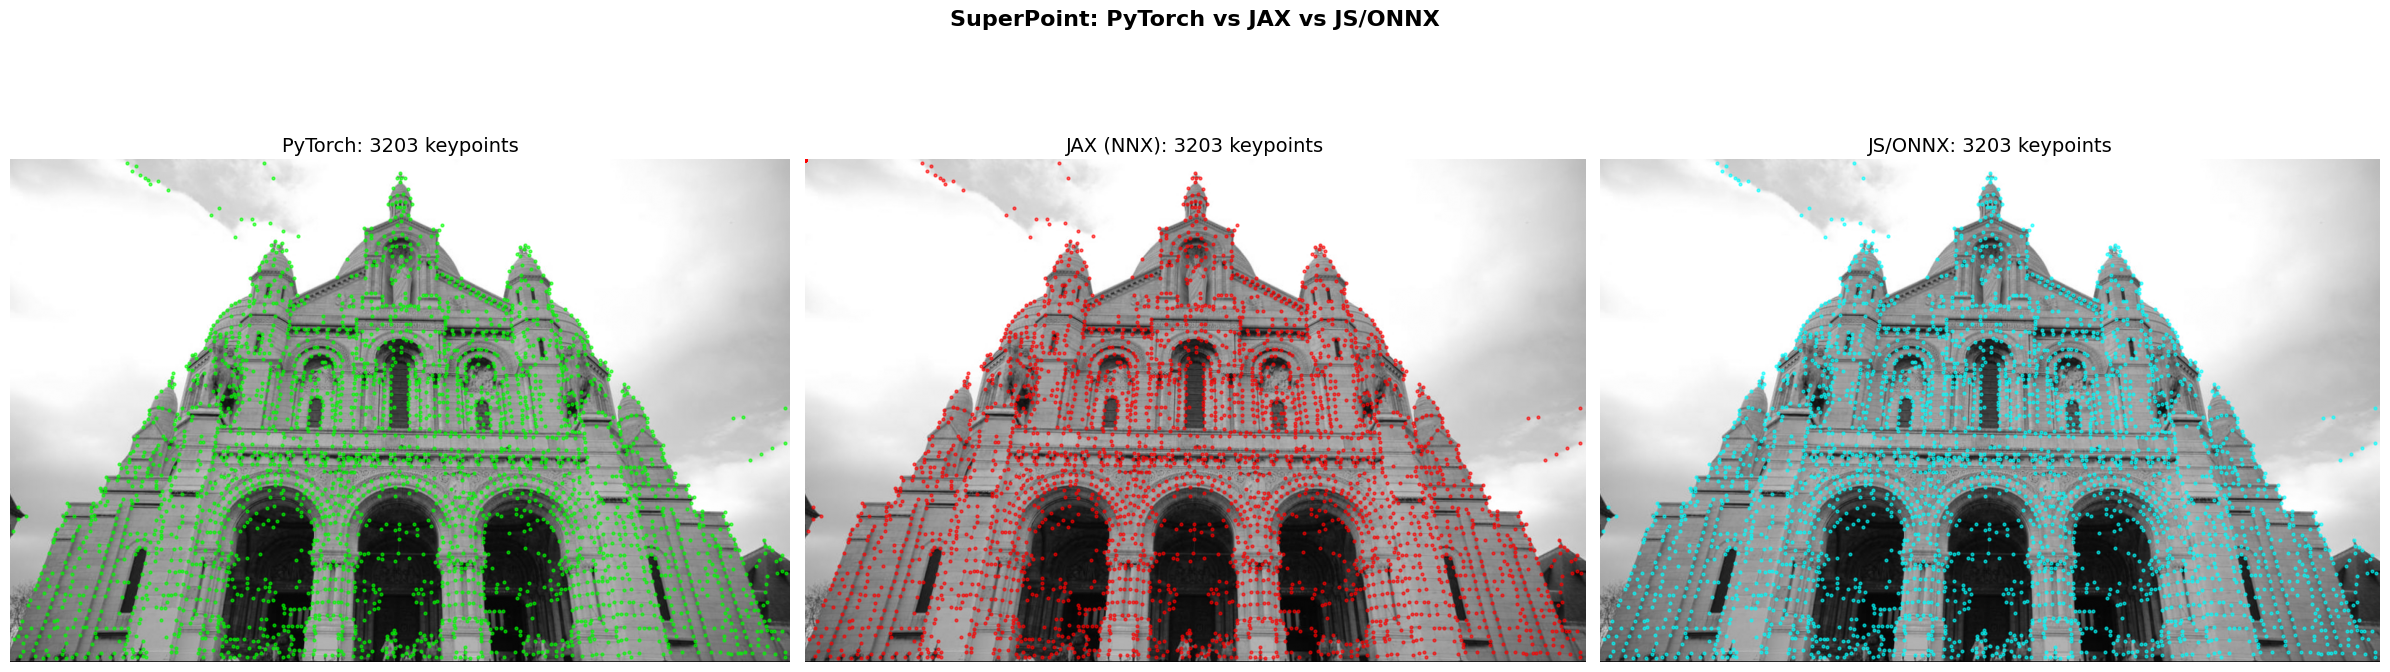

In [26]:
# 3-way comparison: PyTorch vs JAX vs JS/ONNX
fig, axs = plt.subplots(1, 3, figsize=(24, 8))

# PyTorch
axs[0].imshow(image_padded, cmap='gray')
if torch_kpts.size > 0:
    axs[0].scatter(torch_kpts[:, 0], torch_kpts[:, 1], s=4, c='lime', marker='o', alpha=0.6)
axs[0].set_title(f'PyTorch: {len(torch_kpts)} keypoints', fontsize=14)
axs[0].axis('off')

# JAX
axs[1].imshow(image_padded, cmap='gray')
if jax_kpts.size > 0:
    axs[1].scatter(jax_kpts[:, 1], jax_kpts[:, 0], s=4, c='red', marker='o', alpha=0.6)
axs[1].set_title(f'JAX (NNX): {int(jax_output["valid_counts"][0])} keypoints', fontsize=14)
axs[1].axis('off')

# JS/ONNX
axs[2].imshow(image_padded, cmap='gray')
if js_kpts.size > 0:
    axs[2].scatter(js_kpts[:, 0], js_kpts[:, 1], s=4, c='cyan', marker='o', alpha=0.6)
axs[2].set_title(f'JS/ONNX: {len(js_kpts)} keypoints', fontsize=14)
axs[2].axis('off')

plt.suptitle('SuperPoint: PyTorch vs JAX vs JS/ONNX', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
import os

# Download
!wget https://github.com/1kaiser/Media-Segment-Depth-MLP/releases/download/v0.2/input_depthMaps.zip

# Unzip into a specific folder
!unzip -q input_depthMaps.zip -d dataset_depth

# Verify structure
!ls -R dataset_depth | head -n 20

--2026-02-16 17:00:55--  https://github.com/1kaiser/Media-Segment-Depth-MLP/releases/download/v0.2/input_depthMaps.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/578313074/f03a4ff1-46e0-40d7-abe4-33b811505e2e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-02-16T17%3A46%3A58Z&rscd=attachment%3B+filename%3Dinput_depthMaps.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-02-16T16%3A46%3A02Z&ske=2026-02-16T17%3A46%3A58Z&sks=b&skv=2018-11-09&sig=9OuSWiJXCmd7opQekAYtucctGBuxCj60KsNTdGjxgsY%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MTI2NDg1NSwibmJmIjoxNzcxMjYxMjU1LCJwYXRoIjoicmVsZWFzZWFzc2V0

Found 1014 total images.
Randomly selected 50 images for comparison.

Status: 10/50 analyzed...
Status: 20/50 analyzed...
Status: 30/50 analyzed...
Status: 40/50 analyzed...
Status: 50/50 analyzed...

      SUPERPOINT DETECTION COMPARISON TABLE


,ID,Filename,Detections,Confidence (Max),Confidence (Mean)
0,1,frame_0355.png,2220,0.6335,0.1307
1,2,frame_0203.png,2237,0.7130,0.1312
2,3,frame_0719.png,379,0.5570,0.0640
3,4,frame_1011.png,388,0.5824,0.0677
4,5,frame_0125.png,464,0.5206,0.0752
5,6,frame_0276.png,2090,0.6927,0.1326
6,7,frame_0437.png,2228,0.6348,0.1255
7,8,frame_0641.png,2156,0.6742,0.1054
8,9,frame_0747.png,387,0.5773,0.0717
9,10,frame_0356.png,2254,0.6894,0.1255



--- GLOBAL STATISTICS ---
Total Images Analyzed:   50
Avg Detections/Image:    1385.70
Highest Detection Count: 2400
Lowest Detection Count:  338


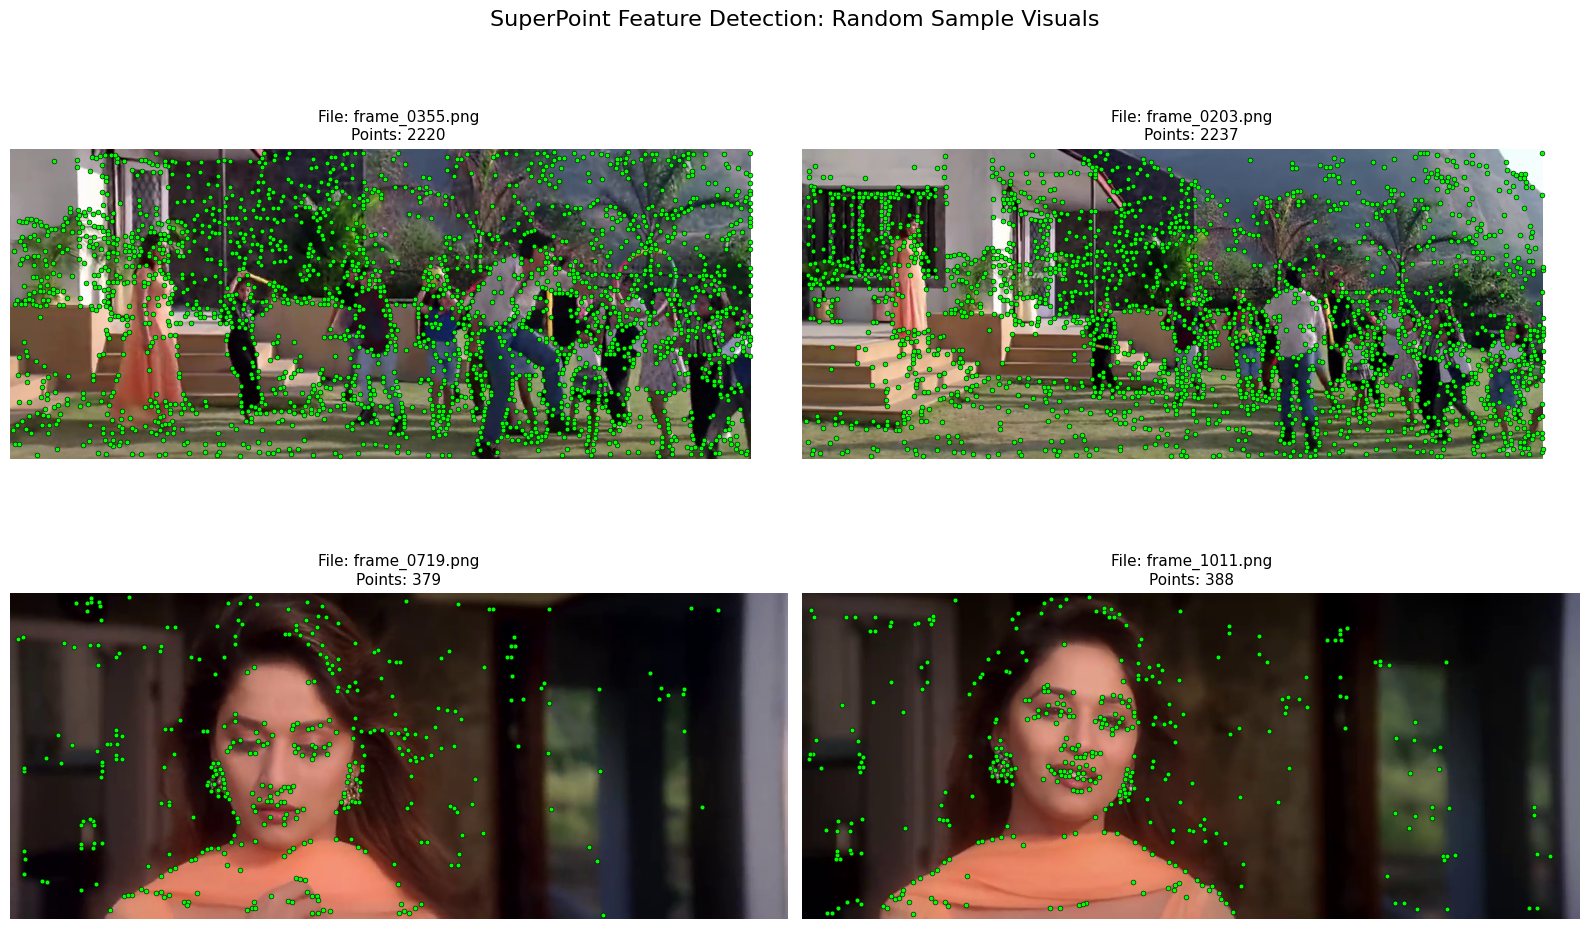

In [29]:
import subprocess
import json as json_mod
import os
import numpy as np
import cv2
import glob
import random
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
BASE_DIR = "/content/superpoint-jax"
JS_DIR = os.path.join(BASE_DIR, "jax-js")
# Using your verified directory path
INPUT_IMG_DIR = "//content/superpoint-jax/dataset_depth/input_frames"
TEMP_GRAY_DIR = "/content/superpoint-jax/temp_grayscale"
RESULTS_DIR = "/content/superpoint-jax/inference_results"

# Ensure directories exist
os.makedirs(TEMP_GRAY_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# 1. Get all images and select 50 random ones
image_files = glob.glob(os.path.join(INPUT_IMG_DIR, "*.*"))
if not image_files:
    print(f"ERROR: No images found in {INPUT_IMG_DIR}. Please check the path.")
else:
    num_to_test = min(len(image_files), 50)
    selected_images = random.sample(image_files, num_to_test)

    print(f"Found {len(image_files)} total images.")
    print(f"Randomly selected {num_to_test} images for comparison.\n")

    table_data = []
    viz_results = []

    # --- 2. PROCESSING LOOP ---
    for i, img_path in enumerate(selected_images):
        img_name = os.path.basename(img_path)
        gray_path = os.path.join(TEMP_GRAY_DIR, f"gray_{img_name}")
        json_path = os.path.join(RESULTS_DIR, f"{img_name}.json")

        # A. Convert to Grayscale manually via OpenCV
        img_rgb = cv2.imread(img_path)
        if img_rgb is None:
            print(f"Skipping {img_name} (could not read)")
            continue

        img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(gray_path, img_gray)

        # B. Run Node.js Inference (Backend Analysis)
        result = subprocess.run(
            ['node', 'compare_helper.js', gray_path, json_path],
            cwd=JS_DIR,
            capture_output=True,
            text=True
        )

        if result.returncode == 0:
            with open(json_path, 'r') as f:
                data = json_mod.load(f)
                kpts = np.array(data['keypoints'])
                scores = np.array(data['scores'])

                # Collect statistics for the Comparison Table
                count = len(kpts)
                max_s = round(float(np.max(scores)), 4) if count > 0 else 0
                mean_s = round(float(np.mean(scores)), 4) if count > 0 else 0

                table_data.append({
                    "ID": i + 1,
                    "Filename": img_name,
                    "Detections": count,
                    "Confidence (Max)": max_s,
                    "Confidence (Mean)": mean_s
                })

                # Keep first 4 for visual sample plotting
                if len(viz_results) < 4:
                    viz_results.append({
                        'name': img_name,
                        'img': img_rgb,
                        'kpts': kpts
                    })

            if (i+1) % 10 == 0:
                print(f"Status: {i+1}/{num_to_test} analyzed...")
        else:
            print(f"Error on {img_name}: {result.stderr}")

    # --- 3. TABULATE RESULTS ---
    df = pd.DataFrame(table_data)
    print("\n" + "="*50)
    print("      SUPERPOINT DETECTION COMPARISON TABLE")
    print("="*50)
    # Using to_string() to ensure the full table shows in logs,
    # or just use display(df) for interactive view
    display(df)

    # --- 4. SUMMARY STATISTICS ---
    print("\n--- GLOBAL STATISTICS ---")
    print(f"Total Images Analyzed:   {len(df)}")
    print(f"Avg Detections/Image:    {df['Detections'].mean():.2f}")
    print(f"Highest Detection Count: {df['Detections'].max()}")
    print(f"Lowest Detection Count:  {df['Detections'].min()}")

    # --- 5. VISUALIZATION ---
    def plot_sample(results):
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        axes = axes.flatten()

        for idx, res in enumerate(results):
            # Display image in RGB
            img_disp = cv2.cvtColor(res['img'], cv2.COLOR_BGR2RGB)
            axes[idx].imshow(img_disp)

            # Plot Green Dots for Detections
            axes[idx].scatter(res['kpts'][:, 0], res['kpts'][:, 1],
                              s=12, c='lime', edgecolors='black', linewidths=0.4)

            axes[idx].set_title(f"File: {res['name']}\nPoints: {len(res['kpts'])}", fontsize=11)
            axes[idx].axis('off')

        plt.tight_layout()
        plt.suptitle("SuperPoint Feature Detection: Random Sample Visuals", fontsize=16, y=1.02)
        plt.show()

    if viz_results:
        plot_sample(viz_results)

In [ ]:
# Quantitative cross-comparison
from scipy.spatial import cKDTree

def count_common(kpts_a, kpts_b, tol=2.0):
    """Count keypoints in A that have a match within tolerance pixels in B."""
    if len(kpts_a) == 0 or len(kpts_b) == 0:
        return 0
    tree = cKDTree(kpts_b)
    dists, _ = tree.query(kpts_a, k=1)
    return int(np.sum(dists <= tol))

# Normalize keypoint formats to (x, y)
torch_xy = torch_kpts                          # already [x, y]
jax_xy = jax_kpts[:, ::-1].copy()              # JAX is [y, x] -> flip
js_xy = js_kpts                                # already [x, y]

pairs = [
    ('PyTorch vs JAX',     torch_xy, jax_xy,  len(torch_xy)),
    ('PyTorch vs JS/ONNX', torch_xy, js_xy,   len(torch_xy)),
    ('JAX vs JS/ONNX',     jax_xy,   js_xy,   len(jax_xy)),
]

print('=' * 55)
print(f'{"Comparison":25s} {"Common (\u00b12px)":>15s} {"Rate":>8s}')
print('=' * 55)
for name, a, b, total in pairs:
    c = count_common(a, b)
    print(f'{name:25s} {c:8d}/{total:<6d} {c/total*100:7.1f}%')
print('=' * 55)
print(f'\nKeypoint counts: PyTorch={len(torch_xy)}, JAX={len(jax_xy)}, JS={len(js_xy)}')